<a href="https://colab.research.google.com/github/SebastianGustavoRojasPeralta/SIS420RojasPeraltaSebastian/blob/main/Laboratorios/Laboratorio01/Laboratorio01RegresionLinealMutivariable.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LABORATORIO 01: PREDICCION DE PM2.5 EN BEIJING**

**Nombre:** Sebastian Gustavo Rojas Peralta
**Dataset:** Histórico climático de Beijing

Este cuadernillo implementa un modelo de **Regresión Lineal Multivariable** orientado a predecir una variable continua (los niveles de contaminación del aire o concentración de PM2.5) a partir de un conjunto de múltiples características climáticas y temporales (como temperatura, humedad, presión, etc.).

Para determinar los parámetros óptimos Theta ($\theta$) y encontrar la relación matemática exacta entre el clima y la contaminación, se usó:
1. **Descenso por Gradiente:** Un método iterativo de optimización que minimiza la función de costo paso a paso.
2. **Ecuación de la Normal:** Una solución analítica directa basada en álgebra matricial para encontrar los parámetros óptimos en un solo cálculo.



**Preparación y limpieza de datos (Actualizado con Pandas)**

Para procesar el histórico del clima de Beijing, se optimizó el flujo de trabajo cambiando la lectura tradicional de numpy por la librería pandas. Estas fueron las decisiones que apliqué para dejar los datos listos para el modelo:

1. **Lectura inteligente del CSV:** En lugar de usar `loadtxt`, usé pd.read_csv. Pandas automáticamente detecta los títulos de las columnas y reconoce los espacios vacíos o textos como "NA", transformándolos en valores nulos (NaN) del sistema.

2. **Limpieza masiva de datos (Imputación):** Como la Regresión Lineal no puede multiplicar letras ni espacios vacíos, necesitaba limpiar esos `NaN`. En vez de crear un bucle manual que revisara celda por celda, usé la función .fillna(0.0). Esto me permitió reemplazar todos los datos faltantes del archivo por `0.0` de golpe, manteniendo la integridad de todas las filas.

3. **Filtro de columnas útiles:** El archivo tiene columnas que no le sirven a la matemática (como el nombre de la ciudad o números de fila). Creé una lista exacta con los índices de las variables climáticas (Año, Mes, Temperatura, Humedad, etc.) y dejé la columna PM_US Post, que es mi contaminación a predecir, estratégicamente al final de la lista.

4. **El puente de vuelta (.values):** Las fórmulas matemáticas del Descenso por Gradiente están diseñadas para matrices puras, no para tablas bonitas de Pandas. Por eso, al momento de extraer mis columnas filtradas (.iloc), le agregué el comando .values. Esto destruye el formato de tabla y me devuelve una matriz rígida de NumPy, garantizando que mi código matemático de las celdas de abajo no se rompa.

5. **Separación de X e y:** Finalmente, como ya había ordenado mi matriz para que la contaminación quedara en la última posición, simplemente dividí la matriz. Todo desde la primera hasta la penúltima columna se fue a mi matriz de causas ($X$), y la última columna se convirtió en mi vector de consecuencias ($y$).


In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

ruta_archivo = '/content/drive/MyDrive/machine learning/datsets/BeijingPM20100101_20151231.csv'

# CARGA CON PANDAS
df = pd.read_csv(ruta_archivo)

# LIMPIEZA DE DATOS
# Reemplazamos todos los valores nulos (NaN) por 0.0
df = df.fillna(0.0)

# Definimos las columnas que queremos extraer
columnas_validas = [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 6]

# EXTRACCIÓN Y CONVERSIÓN A NUMPY
data = df.iloc[:, columnas_validas].values

# Separar X (Características) e y (Variable objetivo)
X = data[:, :-1]
y = data[:, -1]

m = y.size
n = X.shape[1]

print(f"Dataset cargado exitosamente con Pandas.")
print(f"Número de ejemplos (m): {m}")
print(f"Número de características (n): {n}")

# Mostrar los primeros 5 ejemplos
print("\nPrimeros 5 ejemplos de la matriz X:")
print(X[:5, :])

Dataset cargado exitosamente con Pandas.
Número de ejemplos (m): 52584
Número de características (n): 12

Primeros 5 ejemplos de la matriz X:
[[ 2.010e+03  1.000e+00  1.000e+00  0.000e+00  4.000e+00  0.000e+00
   0.000e+00  0.000e+00 -2.100e+01  4.300e+01  1.021e+03 -1.100e+01]
 [ 2.010e+03  1.000e+00  1.000e+00  1.000e+00  4.000e+00  0.000e+00
   0.000e+00  0.000e+00 -2.100e+01  4.700e+01  1.020e+03 -1.200e+01]
 [ 2.010e+03  1.000e+00  1.000e+00  2.000e+00  4.000e+00  0.000e+00
   0.000e+00  0.000e+00 -2.100e+01  4.300e+01  1.019e+03 -1.100e+01]
 [ 2.010e+03  1.000e+00  1.000e+00  3.000e+00  4.000e+00  0.000e+00
   0.000e+00  0.000e+00 -2.100e+01  5.500e+01  1.019e+03 -1.400e+01]
 [ 2.010e+03  1.000e+00  1.000e+00  4.000e+00  4.000e+00  0.000e+00
   0.000e+00  0.000e+00 -2.000e+01  5.100e+01  1.018e+03 -1.200e+01]]


In [2]:
# Mostrar los primeros 10 ejemplos de las primeras 5 características y el valor a predecir
print('{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>12s}'.format('X[:,0]', 'X[:,1]', 'X[:,2]', 'X[:,3]', 'X[:,4]', 'y (PM2.5)'))
print('-' * 55)
for i in range(10):
    print('{:8.0f}{:8.0f}{:8.0f}{:8.0f}{:8.0f}{:12.0f}'.format(X[i, 0], X[i, 1], X[i, 2], X[i, 3], X[i, 4], y[i]))

  X[:,0]  X[:,1]  X[:,2]  X[:,3]  X[:,4]   y (PM2.5)
-------------------------------------------------------
    2010       1       1       0       4           0
    2010       1       1       1       4           0
    2010       1       1       2       4           0
    2010       1       1       3       4           0
    2010       1       1       4       4           0
    2010       1       1       5       4           0
    2010       1       1       6       4           0
    2010       1       1       7       4           0
    2010       1       1       8       4           0
    2010       1       1       9       4           0


**Normalización de las características**

Dado que nuestras variables tienen escalas muy diferentes, el Descenso por Gradiente podría tardar mucho en converger. Aplicamos la Normalización para que todas las variables tengan media 0 y desviación estándar 1.



In [3]:

def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Ejecutamos la función con nuestros datos de Beijing
X_norm, mu, sigma = featureNormalize(X)

# Añadimos la columna de 'unos' para el término de sesgo (theta 0) al X ya normalizado
X_listo = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

# Imprimimos los resultados tal como lo hace el ingeniero
print("Primeros 5 ejemplos de X original:")
print(X[:5, :])
print('\nMedia calculada (mu):', mu)
print('\nDesviación estandar calculada (sigma):', sigma)
print('\nPrimeros 5 ejemplos de X normalizado:')
print(X_norm[:5, :])

Primeros 5 ejemplos de X original:
[[ 2.010e+03  1.000e+00  1.000e+00  0.000e+00  4.000e+00  0.000e+00
   0.000e+00  0.000e+00 -2.100e+01  4.300e+01  1.021e+03 -1.100e+01]
 [ 2.010e+03  1.000e+00  1.000e+00  1.000e+00  4.000e+00  0.000e+00
   0.000e+00  0.000e+00 -2.100e+01  4.700e+01  1.020e+03 -1.200e+01]
 [ 2.010e+03  1.000e+00  1.000e+00  2.000e+00  4.000e+00  0.000e+00
   0.000e+00  0.000e+00 -2.100e+01  4.300e+01  1.019e+03 -1.100e+01]
 [ 2.010e+03  1.000e+00  1.000e+00  3.000e+00  4.000e+00  0.000e+00
   0.000e+00  0.000e+00 -2.100e+01  5.500e+01  1.019e+03 -1.400e+01]
 [ 2.010e+03  1.000e+00  1.000e+00  4.000e+00  4.000e+00  0.000e+00
   0.000e+00  0.000e+00 -2.000e+01  5.100e+01  1.018e+03 -1.200e+01]]

Media calculada (mu): [2012.49977179    6.52396166   15.72660885   11.5           2.49109995
   36.09913662   42.02755591   91.89728815    2.07435722   54.25040887
 1009.91246387   12.5858436 ]

Desviación estandar calculada (sigma): [ 1.70746874  3.44841969  8.79881218  6.9221

**Funciones de Costo y Descenso por Grandiente**

La función de Costo $J(\theta)$ mide qué tan lejos están nuestras predicciones de los valores reales. El Descenso por Gradiente es el algoritmo que ajusta los valores de $\theta$ (pesos) de forma iterativa para minimizar ese error, moviéndose en la dirección opuesta al gradiente de la función de costo.

In [4]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    h = np.dot(X, theta) # Hipótesis
    J = (1/(2 * m)) * np.sum(np.square(h - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    J_history = []
    theta = theta.copy()

    for i in range(num_iters):
        h = np.dot(X, theta)
        theta = theta - (alpha / m) * np.dot(X.T, (h - y))
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

**Entrenamiento del modelo**

Configuramos los hiperparámetros con una tasa de aprendizaje ($\alpha = 0.01$) sobre 1000 iteraciones. Finalizado el proceso, graficamos el historial del costo para validar la convergencia del algoritmo. La disminución progresiva del error confirma que el modelo logró ajustarse a los datos.

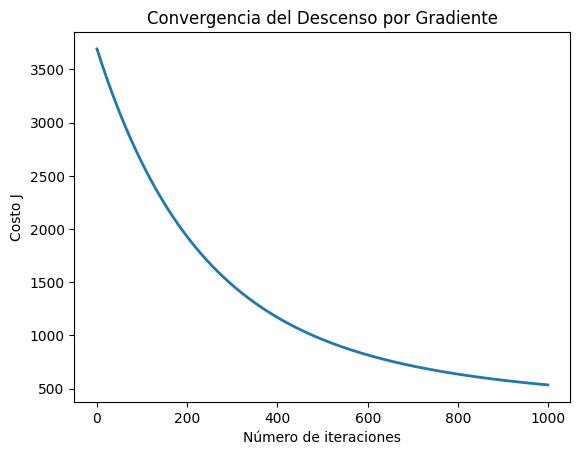


Los valores de Theta encontrados por el Descenso por Gradiente son:
[26.85703583 12.72200927 -0.96189327  0.7359744   1.08820085  1.18032287
 20.27627789 30.35754311 12.50011839  0.70030591  2.26089333 -2.19159758
 -1.07350509]


In [5]:

alpha = 0.001
num_iters = 1000

# Inicializamos theta con ceros.
theta = np.zeros(X_listo.shape[1])

# Ejecutamos el descenso por gradiente asegurándonos de pasarle X_listo
theta, J_history = gradientDescentMulti(X_listo, y, theta, alpha, num_iters)

# 4. Graficamos la convergencia del costo
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del Descenso por Gradiente')
plt.show()

# Imprimimos los resultados finales para comprobar que ya no salen 'nan'
print('\nLos valores de Theta encontrados por el Descenso por Gradiente son:')
print(theta)

**Ecuación de la normal**

$$\theta = (X^T X)^{-1} X^T y$$

A continuación, calcularemos los valores de $\theta$ usando esta fórmula y realizaremos una predicción de la concentración de PM2.5 utilizando datos climáticos hipotéticos sin normalizar.

In [6]:
def normalEqn(X, y):
    # Calculamos theta usando la fórmula: theta = (X^T * X)^-1 * X^T * y
    # np.linalg.inv calcula la inversa de una matriz
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

# Para la Ecuación de la Normal usamos los datos sin normalizar.
# Solo le añadimos la columna de unos al principio.
X_original = X # Usamos la variable X que ya contiene las características originales
X_normal = np.concatenate([np.ones((m, 1)), X_original], axis=1)

# Calcula los parametros con la ecuación de la normal
theta_normal = normalEqn(X_normal, y)

# Muestra los resultados obtenidos
print('Theta calculado a partir de la ecuación de la normal:')
print(theta_normal)
print('-' * 60)

# Estimar la contaminación de PM2.5 para un día inventado
# Características: [Sesgo, Año, Mes, Día, Hora, Temporada, DEWP, HUMI, PRES, TEMP, Iws, precipitación, Iprec]
# Total: 1 (sesgo) + 12 características = 13 elementos

X_array = [1, 2015, 12, 1, 12, 4, -10.0, 50.0, 1020.0, -5.0, 5.0, 0.0, 0.0]

# Multiplicamos nuestro dato inventado por el theta calculado
prediccion = np.dot(X_array, theta_normal)

print(f'Contaminación PM2.5 predicha para estas condiciones climáticas: {prediccion:.2f} ug/m^3')

Theta calculado a partir de la ecuación de la normal:
[-4.86886400e+03  2.42256649e+00 -3.67324981e-01 -6.47309272e-04
  1.28244978e-01  2.54837911e-01  8.09087439e-02  8.33350583e-01
  4.13458158e-02 -9.31010815e-02  4.43441816e-02 -1.00657185e-02
  1.93091770e-01]
------------------------------------------------------------
Contaminación PM2.5 predicha para estas condiciones climáticas: 94.48 ug/m^3
